 Данные загружены. Размер: (7, 21)


,Year,DeFi,Stablecoins,NFT,Gaming & Metaverse,Layer-1 Blockchains,Layer-2 / Scaling,Bridges & Interoperability,Infrastructure & Oracles,RWA Tokenization,...,Decentralized Identity (DID),Web3 Social Platforms,Privacy Coins & Tech,Security & Auditing,DAO Infrastructure,CBDC & RegTech,Green Blockchain / ESG,Supply Chain & Logistics,Web3 Infrastructure Services,DePIN (Decentralized Physical Infra)
0,2019,1.1,5.0,0.03,0.5,30.0,0.5,0.2,1.0,NaN,...,0.05,NaN,1.5,0.2,0.05,NaN,0.02,0.4,1.0,NaN
1,2020,6.8,28.0,0.25,1.2,50.0,1.0,0.5,3.5,NaN,...,0.10,NaN,2.0,0.4,0.30,1.0,0.05,0.8,2.0,NaN
2,2021,112.4,155.0,25.00,30.0,120.0,4.0,3.0,10.0,0.1,...,0.30,0.2,3.0,1.0,2.50,3.0,0.20,2.0,5.0,NaN
3,2022,75.3,180.0,20.00,25.0,100.0,7.0,5.0,8.0,0.5,...,0.80,0.6,3.5,2.0,2.00,5.0,0.50,2.5,7.0,0.3
4,2023,95.0,130.0,12.00,15.0,85.0,10.0,7.0,12.0,2.0,...,1.50,1.0,4.0,3.5,1.50,6.5,1.00,3.0,9.0,1.0


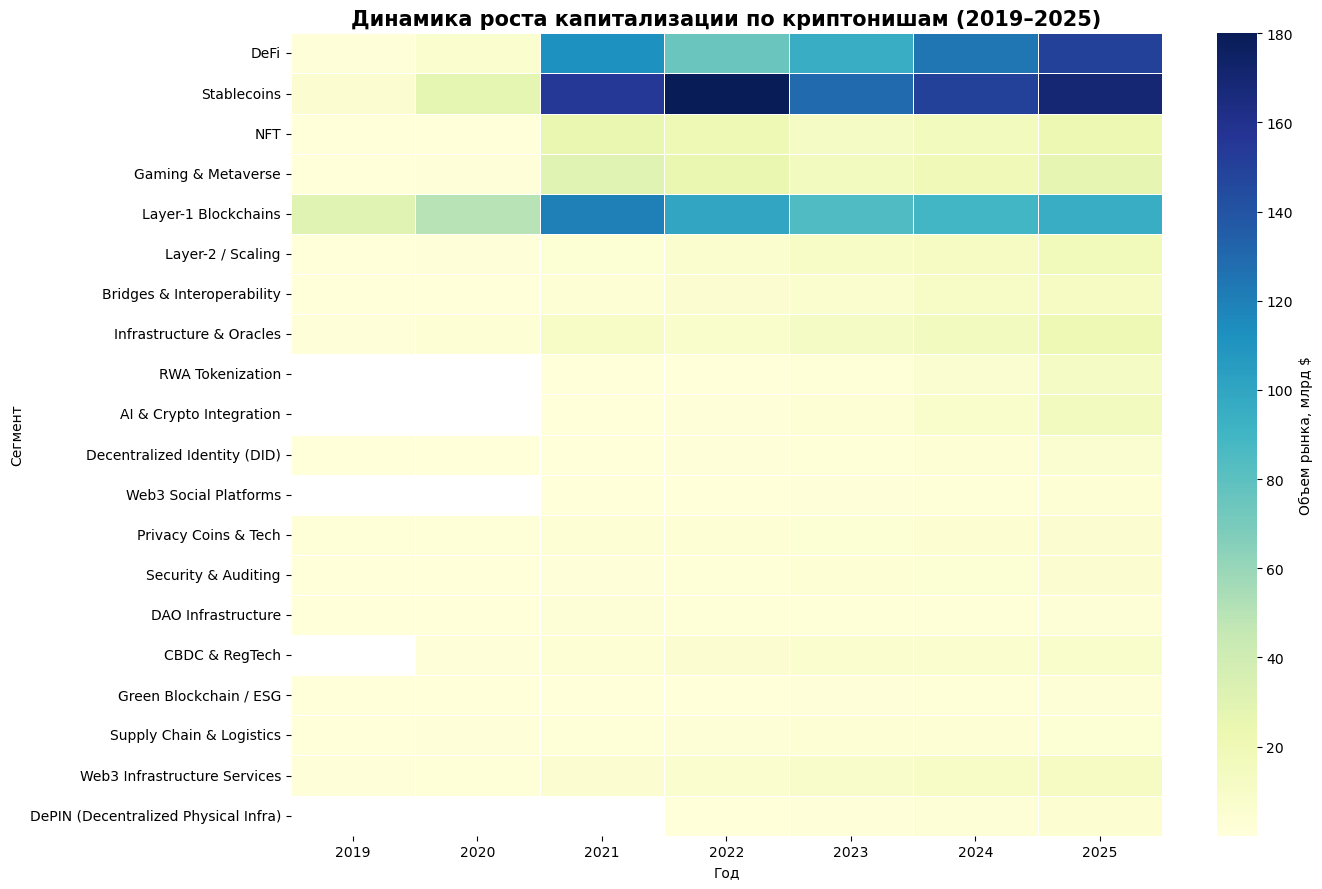

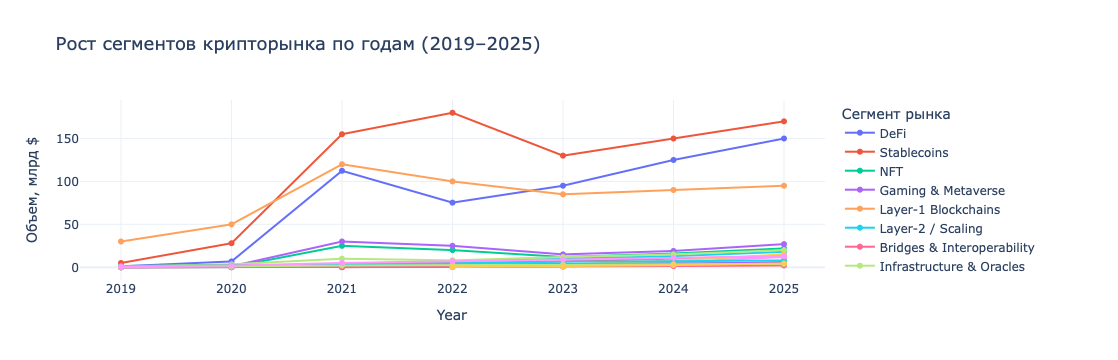

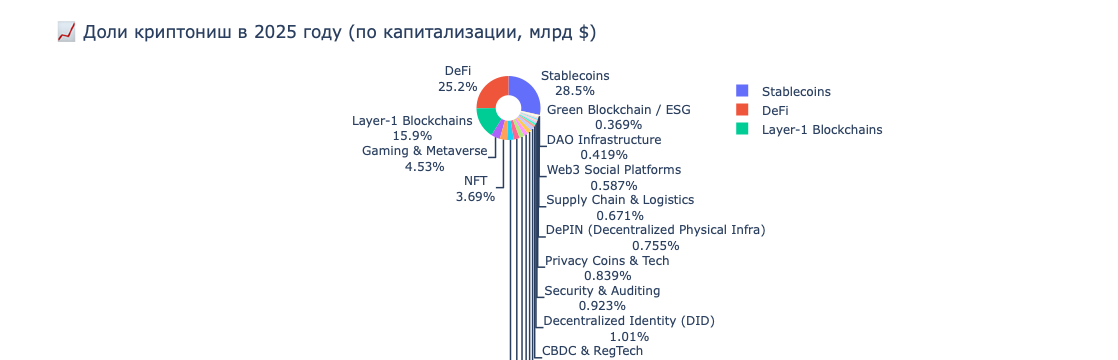

Визуализация завершена успешно!


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1.Загрузка данных
df = pd.read_csv("crypto_trends_2019_2025.csv")

# Проверим структуру
print(" Данные загружены. Размер:", df.shape)
display(df.head())

# 2.Тепловая карта динамики
plt.figure(figsize=(14, 9))
sns.heatmap(
    df.set_index("Year").T,
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Объем рынка, млрд $'}
)
plt.title("Динамика роста капитализации по криптонишам (2019–2025)", fontsize=15, weight="bold")
plt.xlabel("Год")
plt.ylabel("Сегмент")
plt.tight_layout()
plt.show()

#3. Линейный график трендов
df_melt = df.melt(id_vars="Year", var_name="Сегмент", value_name="Объем, млрд $")

fig = px.line(
    df_melt,
    x="Year",
    y="Объем, млрд $",
    color="Сегмент",
    title="Рост сегментов крипторынка по годам (2019–2025)",
    markers=True,
    hover_name="Сегмент"
)
fig.update_layout(
    template="plotly_white",
    legend_title_text="Сегмент рынка",
    title_font_size=18
)
fig.show()

# 4. Pie Chart: доли в 2025 году 
df_2025 = df[df["Year"] == 2025].set_index("Year").T
df_2025 = df_2025.reset_index().rename(columns={"index": "Сегмент", 2025: "Объем, млрд $"})

fig_pie = px.pie(
    df_2025,
    values="Объем, млрд $",
    names="Сегмент",
    title="Доли криптониш в 2025 году (по капитализации, млрд $)",
    hole=0.4
)
fig_pie.update_traces(textinfo="percent+label")
fig_pie.update_layout(template="plotly_white")
fig_pie.show()

print("Визуализация завершена успешно!")
